# **PRIMER PARCIAL 02/2025**
**Nombre del data set:**
Beijing Multi-Site Air Quality

**link:** https://archive.ics.uci.edu/dataset/501/beijing%2Bmulti%2Bsite%2Bair%2Bquality%2Bdata

**Descripcion:** Este conjunto de datos corresponde a registros horarios de la calidad del aire en 12 estaciones diferentes de la ciudad de Beijing (China), recopilados entre el 1 de marzo de 2013 y el 28 de febrero de 2017.

# 1. **Importar librerías**

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

# 2. **Montar Google Drive y cargar dataset**

In [112]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Ruta según del archivo

In [113]:
file_path = '/content/drive/MyDrive/Programas de IA/parciales/primerParcial/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv'
df = pd.read_csv(file_path)

print("Shape del dataset:", df.shape)
df.head()

Shape del dataset: (35064, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


# 3. **Verificar valores nulos en cada columna y rellenar si existen con la media ademas con la moda si es que hay con texto**

In [114]:
# Crear columna datetime
df['date'] = pd.to_datetime(df[['year','month','day','hour']])
df = df.set_index('date')

# Verificar nulos antes
print("Valores nulos antes de imputar:")
print(df.isnull().sum())

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Rellenar nulos en columnas numéricas con la media
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Para la columna 'wd' (dirección del viento), rellenar con la moda
if 'wd' in df.columns:
    df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

# Codificar 'wd' con One-Hot Encoding
df = pd.get_dummies(df, columns=['wd'])

# Verificar nulos después
print("\nValores nulos después de imputar:")
print(df.isnull().sum())


Valores nulos antes de imputar:
No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

Valores nulos después de imputar:
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
WSPM       0
station    0
wd_E       0
wd_ENE     0
wd_ESE     0
wd_N       0
wd_NE      0
wd_NNE     0
wd_NNW     0
wd_NW      0
wd_S       0
wd_SE      0
wd_SSE     0
wd_SSW     0
wd_SW      0
wd_W       0
wd_WNW     0
wd_WSW     0
dtype: int64


# 4. **Selección de variable objetivo y normalización**

In [115]:
from sklearn.preprocessing import MinMaxScaler

# Usaremos solo PM2.5 como variable objetivo
data = df[['PM2.5']].resample('D').mean()

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data[['PM2.5']].values)


# 5. **Ventanas deslizantes (120 días -> 30 días)**

In [116]:
def create_sequences(data, input_len=120, output_len=30):
    X, y = [], []
    for i in range(len(data)-input_len-output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, 120, 30)

print("Forma de X:", X.shape)  # (samples, steps, features)
print("Forma de y:", y.shape)

Forma de X: (1311, 120, 1)
Forma de y: (1311, 30, 1)


# 6. **Convertir a tensores y dividir en train/test**

In [117]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)

# 80% train, 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

#  7. **Modelo LSTM con input_size dinámico**

In [118]:
import torch.nn as nn

num_features = X.shape[2]  # número de features reales

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=30):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel(input_size=num_features)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Modelo creado con input_size={num_features}")

Modelo creado con input_size=1


In [110]:
EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        yb = yb.squeeze(-1)   # <-- corrección aquí
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss/len(train_loader):.4f}")



Epoch 1/50, Train Loss: 0.0188
Epoch 2/50, Train Loss: 0.0187
Epoch 3/50, Train Loss: 0.0186
Epoch 4/50, Train Loss: 0.0187
Epoch 5/50, Train Loss: 0.0188
Epoch 6/50, Train Loss: 0.0187
Epoch 7/50, Train Loss: 0.0187
Epoch 8/50, Train Loss: 0.0185
Epoch 9/50, Train Loss: 0.0186
Epoch 10/50, Train Loss: 0.0184
Epoch 11/50, Train Loss: 0.0188
Epoch 12/50, Train Loss: 0.0186
Epoch 13/50, Train Loss: 0.0187
Epoch 14/50, Train Loss: 0.0185
Epoch 15/50, Train Loss: 0.0187
Epoch 16/50, Train Loss: 0.0186
Epoch 17/50, Train Loss: 0.0186
Epoch 18/50, Train Loss: 0.0186
Epoch 19/50, Train Loss: 0.0184
Epoch 20/50, Train Loss: 0.0183
Epoch 21/50, Train Loss: 0.0183
Epoch 22/50, Train Loss: 0.0182
Epoch 23/50, Train Loss: 0.0183
Epoch 24/50, Train Loss: 0.0185
Epoch 25/50, Train Loss: 0.0182
Epoch 26/50, Train Loss: 0.0183
Epoch 27/50, Train Loss: 0.0183
Epoch 28/50, Train Loss: 0.0182
Epoch 29/50, Train Loss: 0.0183
Epoch 30/50, Train Loss: 0.0182
Epoch 31/50, Train Loss: 0.0182
Epoch 32/50, Trai

In [119]:
with torch.no_grad():
    for xb, yb in test_loader:
        yb = yb.squeeze(-1)   # <-- corrección aquí
        y_pred = model(xb)
        break


# 8. **Evaluación en test y gráfico**

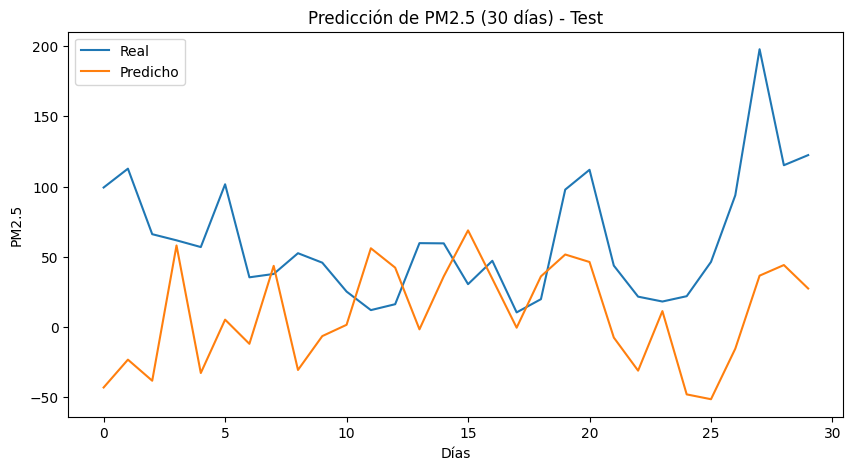

In [120]:
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        yb = yb.squeeze(-1)   # <-- corrección
        y_pred = model(xb)
        break  # solo un batch para graficar

# Invertir la normalización
y_real = scaler.inverse_transform(yb[0].numpy().reshape(-1,1))
y_predicted = scaler.inverse_transform(y_pred[0].numpy().reshape(-1,1))

# Graficar
plt.figure(figsize=(10,5))
plt.plot(y_real, label="Real")
plt.plot(y_predicted, label="Predicho")
plt.title("Predicción de PM2.5 (30 días) - Test")
plt.xlabel("Días")
plt.ylabel("PM2.5")
plt.legend()
plt.show()

In [121]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

mse = mean_squared_error(y_real, y_predicted)
mae = mean_absolute_error(y_real, y_predicted)
rmse = math.sqrt(mse)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MSE: 5563.03
MAE: 61.51
RMSE: 74.59


# **Hacer predicción futura (más allá del test set)**

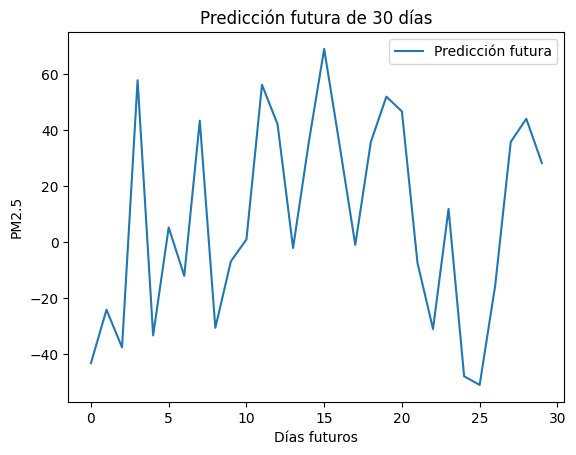

In [122]:
last_sequence = torch.tensor(X[-1:], dtype=torch.float32)  # última ventana de entrada
with torch.no_grad():
    future_pred = model(last_sequence).numpy()

# Desnormalizar
future_pred = scaler.inverse_transform(future_pred.reshape(-1,1))

plt.plot(future_pred, label="Predicción futura")
plt.title("Predicción futura de 30 días")
plt.xlabel("Días futuros")
plt.ylabel("PM2.5")
plt.legend()
plt.show()


In [123]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_real, y_predicted)
print(f"MAPE: {mape:.2f}%")


MAPE: 119.46%
